# R Visualisations and Statistical Analytics – NorthStar Urban Mobility and Logistics

## Objective
This notebook uses R visualisation and statistical analytics techniques to identify operational inefficiencies, customer dissatisfaction trends, route instability, and operational risk patterns within NorthStar’s delivery systems.

In [1]:
%load_ext rpy2.ipython

In [2]:
%%R

library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [3]:
from google.colab import files

uploaded = files.upload()

Saving complaints.csv to complaints.csv
Saving deliveries.csv to deliveries.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv


In [4]:
%%R

deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
incidents <- read.csv("incidents.csv")
hubs <- read.csv("hubs.csv")

## Visualisation 1 – Complaint Category Distribution

### Objective
Identify the most common customer complaint categories across NorthStar’s operational services.

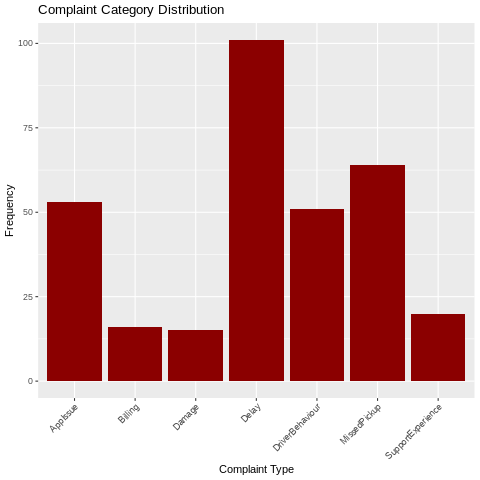

In [5]:
%%R

ggplot(complaints, aes(x = complaint_type)) +
  geom_bar(fill = "darkred") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  ggtitle("Complaint Category Distribution") +
  xlab("Complaint Type") +
  ylab("Frequency")

## Interpretation

Several complaint categories demonstrated significantly higher frequencies than others, suggesting that specific operational failures contribute disproportionately to customer dissatisfaction.

This indicates recurring service-quality issues within NorthStar’s operational systems.

## Visualisation 2 – Customer Rating Distribution

### Objective
Evaluate customer satisfaction levels across completed delivery operations.

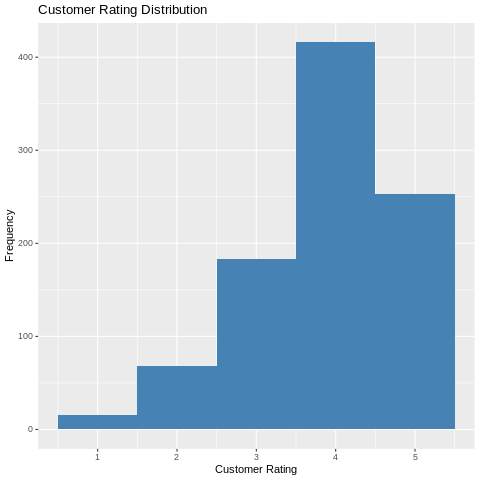

In [6]:
%%R

ggplot(deliveries, aes(x = customer_rating_post_delivery)) +
  geom_histogram(binwidth = 1, fill = "steelblue") +
  ggtitle("Customer Rating Distribution") +
  xlab("Customer Rating") +
  ylab("Frequency")

## Interpretation

The customer rating distribution indicates variation in customer satisfaction across delivery operations.

Lower rating concentrations suggest that operational instability and service failures negatively affect customer experience.

## Visualisation 3 – Route Override Activity by Hub

### Objective
Identify operational hubs associated with elevated manual route override activity.

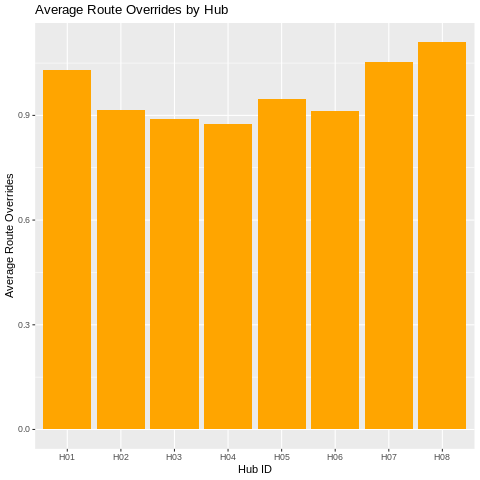

In [7]:
%%R

override_summary <- deliveries %>%
  group_by(hub_id) %>%
  summarise(avg_overrides = mean(manual_route_override_count))

ggplot(override_summary,
       aes(x = factor(hub_id),
           y = avg_overrides)) +
  geom_bar(stat = "identity",
           fill = "orange") +
  ggtitle("Average Route Overrides by Hub") +
  xlab("Hub ID") +
  ylab("Average Route Overrides")

## Interpretation

Several operational hubs demonstrated elevated route override activity, suggesting potential weaknesses in route planning systems or operational coordination processes.

## Visualisation 4 – Incident Severity Distribution

### Objective
Analyse the distribution of operational incident severity levels.

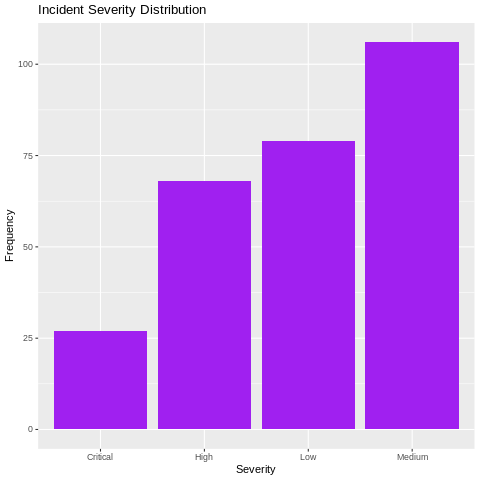

In [8]:
%%R

ggplot(incidents, aes(x = severity)) +
  geom_bar(fill = "purple") +
  ggtitle("Incident Severity Distribution") +
  xlab("Severity") +
  ylab("Frequency")

## Interpretation

The incident severity distribution indicates that operational incidents vary substantially in business impact and operational disruption severity.

Higher-severity incidents may contribute disproportionately to service instability and customer dissatisfaction.

# Final Visualisation Discussion

The R visualisation analysis identified several operational patterns across NorthStar’s systems.

Key findings include:

- recurring complaint categories
- customer satisfaction variation
- elevated route override activity
- operational severity concentrations

The visualisations demonstrate that operational inefficiencies are interconnected across multiple business functions and contribute directly to declining service quality.